# Latent-space discovery of metastable dynamical regimes

Here we are interested in decomposing the static ponderomotive instability of superconducting radio frequency cavities.

In [1]:
import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..', '..'))
sys.path.append(root_dir)

data_dir = f'{root_dir}/data/regimes/cavity_fold'
model_dir = f'{root_dir}/models/regimes/duffing'

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import kind
import util_data
import util_nn

### Read windows data

In [2]:
# --! set seed to get reproducible behavior
util_nn.set_seed(2026)

In [3]:
class regime_dataset(torch.utils.data.Dataset):

    def __init__(self, data, back_nsample, fore_nsample):

        self.data = torch.as_tensor(data)

        self.back_nsample = back_nsample
        self.fore_nsample = fore_nsample

        self.index = []

        ntraj = self.data.shape[0]
        nsample = self.data.shape[1]

        for traj_id in range(ntraj):

            for center in range(back_nsample,
                                nsample - fore_nsample):

                self.index.append(
                    (traj_id, center)
                )

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):

        traj_id, center = self.index[idx]

        x = self.data[traj_id]

        back = x[
            center-self.back_nsample:center
        ]

        fore = x[
            center:center+self.fore_nsample
        ]

        return (
            back,
            fore,
            traj_id,
            center
        )

In [4]:
def normalize_standard(timeseries, mean, std):
    return (timeseries - mean) / std

def denormalize_standard(timeseries, mean, std):
    return timeseries * std + mean

class dataset(torch.utils.data.Dataset):
    def __init__(self, back, fore):
        self.back = back
        self.fore = fore

    def __len__(self):
        return len(self.back)

    def __getitem__(self, idx):
        return self.back[idx], self.fore[idx]

# --! read windows data from a file
traj_nsample = 2000
window_nsample = 72
data = util_data.read_datafile(f'{data_dir}/trajectories', traj_nsample)
print(f'inf > read data shape: {data.shape}')

ntraj = data.shape[0]
nwindow = traj_nsample - window_nsample
print(f'inf > number of read trajectories is {ntraj}')
print(f'inf > number of {window_nsample}-sample windows in read trajectories is {nwindow}')

# --! get normalization constants per channel
std_min = torch.tensor(1e-3, dtype=torch.float32)
data_mean = [d.mean() for d in torch.split(data, 1, dim=-1)]
data_std = [torch.maximum(d.std(), std_min) for d in torch.split(data, 1, dim=-1)]

# --! normalize data
data = torch.cat([
    normalize_standard(
        d, mean, std) for d, mean, std in zip(torch.split(data, 1, dim=-1), data_mean, data_std)], dim=-1)

# --! split windows into lookback and forecast parts
fore_nsample = 24
back_nsample = 2 * fore_nsample

dataset = regime_dataset(data, back_nsample, fore_nsample)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=False)

inf > read data shape: torch.Size([8, 2000, 2])
inf > number of read trajectories is 8
inf > number of 72-sample windows in read trajectories is 1928


### Instantiate past and future regime encoders

The idea is to train a latent space that is future-aware. When our trained encoder looks at past data (from a lookback window) it is expected to produce a coordinate $c_t$ which represents the evolution of dynamics. A threshold can later be derived to separate various dynamical regimes.

In [5]:
# --! instantiate encoders
window_ndim = data.shape[-1]
latent_ndim = 3
back_enc = kind.regime_encoder(back_nsample, window_ndim, latent_ndim)
fore_enc = kind.regime_encoder(fore_nsample, window_ndim, latent_ndim)

In [6]:
def slow_feature_loss(z, traj_id, center, lag=1):
    loss = 0.0
    count = 0

    for traj in torch.unique(traj_id):

        idx = (traj_id == traj)

        z_traj = z[idx]
        c_traj = center[idx]

        order = torch.argsort(c_traj)

        z_traj = z_traj[order]

        dz = z_traj[lag:] - z_traj[:-lag]

        loss += (dz**2).mean()

        count += 1

    return loss / max(count,1)

def variance_loss(z):

    std = torch.sqrt(z.var(dim=0) + 1e-4)
    return torch.mean(torch.relu(1.0 - std))

def train_enc(back_enc, fore_enc, dataloader, nepoch=100, lag=1):
    optimizer = torch.optim.Adam(list(back_enc.parameters()) + list(fore_enc.parameters()), lr=1e-3)

    for epoch in range(nepoch):
        total_loss = 0.0

        for back, fore, traj_id, center in dataloader:
            z = back_enc(torch.flatten(back, start_dim=1))
            h = fore_enc(torch.flatten(fore, start_dim=1))

            loss_future = F.mse_loss(z, h)
            loss_var_z = variance_loss(z)
            loss_var_h = variance_loss(h)

            loss_slow = slow_feature_loss(z[:, 2], traj_id, center, lag=lag)

            loss = (
                loss_future
                + 0.01 * loss_var_z + 0.01 * loss_var_h
                + 0.1 * loss_slow
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"epoch {epoch}, loss: {total_loss / len(dataloader):.6f}")


In [7]:
train_enc(back_enc, fore_enc, dataloader, nepoch=200, lag=10)

epoch 0, loss: 0.045447
epoch 20, loss: 0.019660
epoch 40, loss: 0.019257
epoch 60, loss: 0.019176
epoch 80, loss: 0.019111
epoch 100, loss: 0.019445
epoch 120, loss: 0.018159
epoch 140, loss: 0.017440
epoch 160, loss: 0.019986
epoch 180, loss: 0.021629


In [8]:
# --! load all data
back, fore, traj_id, center = zip(*[batch for batch in dataloader])

# --! convert tuples into tensors
back = torch.cat(back, dim=0)
traj_id = torch.cat(traj_id, dim=0)

In [9]:
# --! encode lookback windows
z = back_enc(torch.flatten(back, start_dim=1))

In [10]:
# --! split data according to trajectories
zs = torch.stack(torch.split(z, nwindow, dim=0))
backs = torch.stack(torch.split(back, nwindow, dim=0))

print(f'inf > shape of z latent space per trajectory is {zs.shape}')
print(f'inf > shape of lookback windows per trajectory is {backs.shape}')

inf > shape of z latent space per trajectory is torch.Size([8, 1928, 3])
inf > shape of lookback windows per trajectory is torch.Size([8, 1928, 48, 2])


In [11]:
# --! derive local descriptors --!

def make_desc(z, window_nsample=16):

    nsample = len(z)
    descs = []

    for center in range(window_nsample, nsample - window_nsample):
        window = z[center-window_nsample:center+window_nsample]
        cov = np.cov(window.T)
        eigvals = np.linalg.eigvalsh(cov)

        descs.append(eigvals)

    return np.stack(descs)

desc_window_nsample = 16
descs = []

for z in zs:
    z = z.detach().cpu().numpy()
    desc = make_desc(z, window_nsample=desc_window_nsample)

    descs.append(desc)

descs = np.stack(descs)

print(f'inf > shape of local descriptors per trajectory is {descs.shape}')

inf > shape of local descriptors per trajectory is (8, 1896, 3)


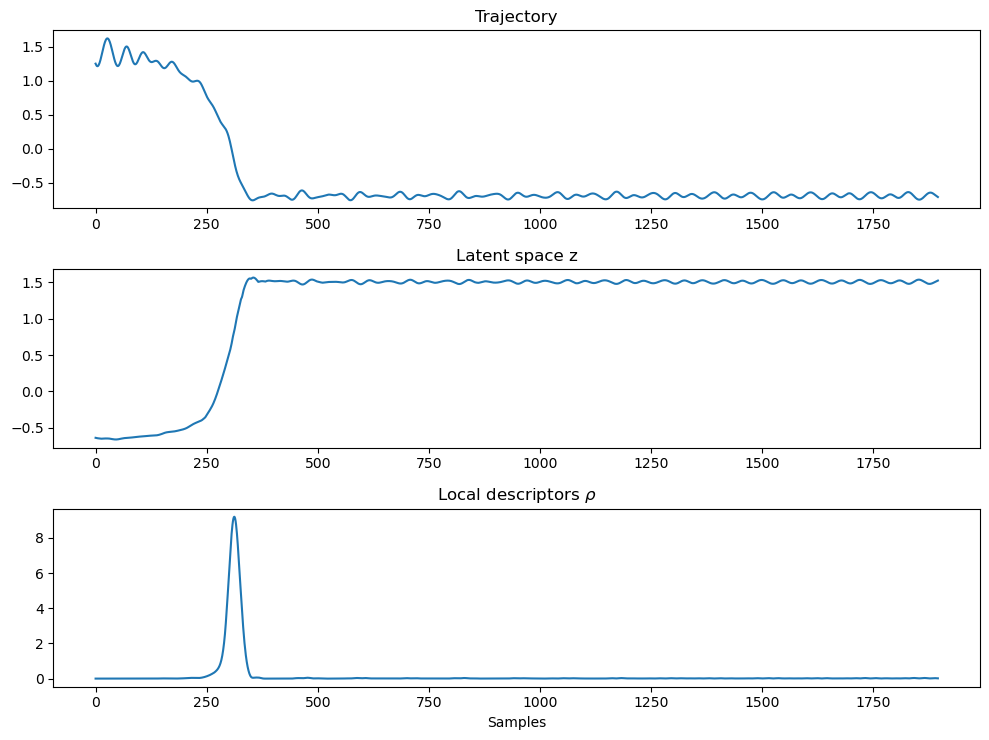

In [12]:
# --! plot local descriptors --!

x = backs[0][:, -1, 1]
x = x[desc_window_nsample:-desc_window_nsample]

plt.figure(figsize=(10, 7.5))

plt.subplot(3,1,1)
plt.title('Trajectory')
plt.plot(x)

z = zs[0].detach().cpu().numpy()
c = z[desc_window_nsample:-desc_window_nsample, 2]
plt.subplot(3,1,2)
plt.title('Latent space z')
plt.plot(c)

d = descs[0, :, 2]
d = d / np.std(d)
plt.subplot(3,1,3)
plt.title('Local descriptors $\\rho$')
plt.plot(d)
plt.xlabel('Samples')

plt.tight_layout()
plt.show()

In [13]:
# --! hepling classes and methods --!

class descriptor_dataset(torch.utils.data.Dataset):

    def __init__(self, data, window_nsample=16):

        self.data = torch.as_tensor(data, dtype=torch.float32)
        self.window_nsample = window_nsample

        self.index = []
        ntraj = self.data.shape[0]
        nsample = self.data.shape[1]

        for traj_id in range(ntraj):
            for center in range(window_nsample, nsample - window_nsample):

                self.index.append(
                    (traj_id, center)
                )

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):

        traj_id, center = self.index[idx]
        window = self.data[traj_id, center-self.window_nsample:center+self.window_nsample, 2]

        return window

class descriptor_classifier(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.features = torch.nn.Sequential(

            torch.nn.Conv1d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                padding=2
            ),

            torch.nn.ReLU(),

            torch.nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),

            torch.nn.ReLU(),

            torch.nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = torch.nn.Linear(32, 2)

    def forward(self, x):

        x = self.features(x)

        x = x.squeeze(-1)

        return self.classifier(x)



In [14]:
class_window_nsample = 16

desc_dataset = descriptor_dataset(descs, window_nsample=class_window_nsample)
desc_dataloader = torch.utils.data.DataLoader(
    desc_dataset,
    batch_size=256,
    shuffle=False
)

desc_classifier = descriptor_classifier()
desc_classifier.load_state_dict(torch.load(f'{model_dir}/classifier.pth'))
desc_classifier.eval()

descriptor_classifier(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (3): ReLU()
    (4): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)

In [15]:
descs = [batch for batch in desc_dataloader]

# --! convert tuples into tensors and reshape into trajectories
descs = torch.cat(descs, dim=0)
descs = descs.reshape(ntraj, -1, descs.shape[-1])

jtraj = 7
window = descs[jtraj]
window = window / torch.std(window)
classes = []
for w in window:
    o = desc_classifier(torch.unsqueeze(w, 0))
    classes.append(o)
classes = torch.stack(classes)
classes = classes.detach().cpu().numpy()


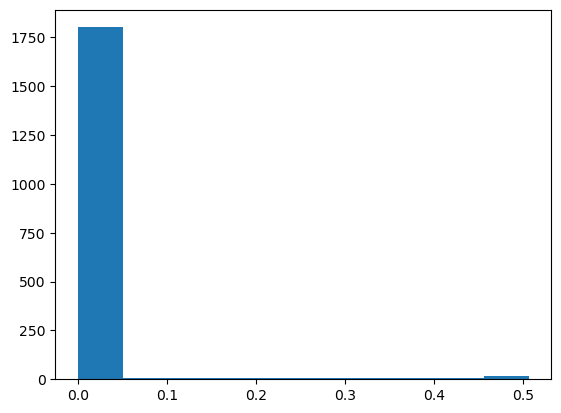

In [16]:
plt.figure()
plt.hist(descs[jtraj, :, 2])
plt.show()

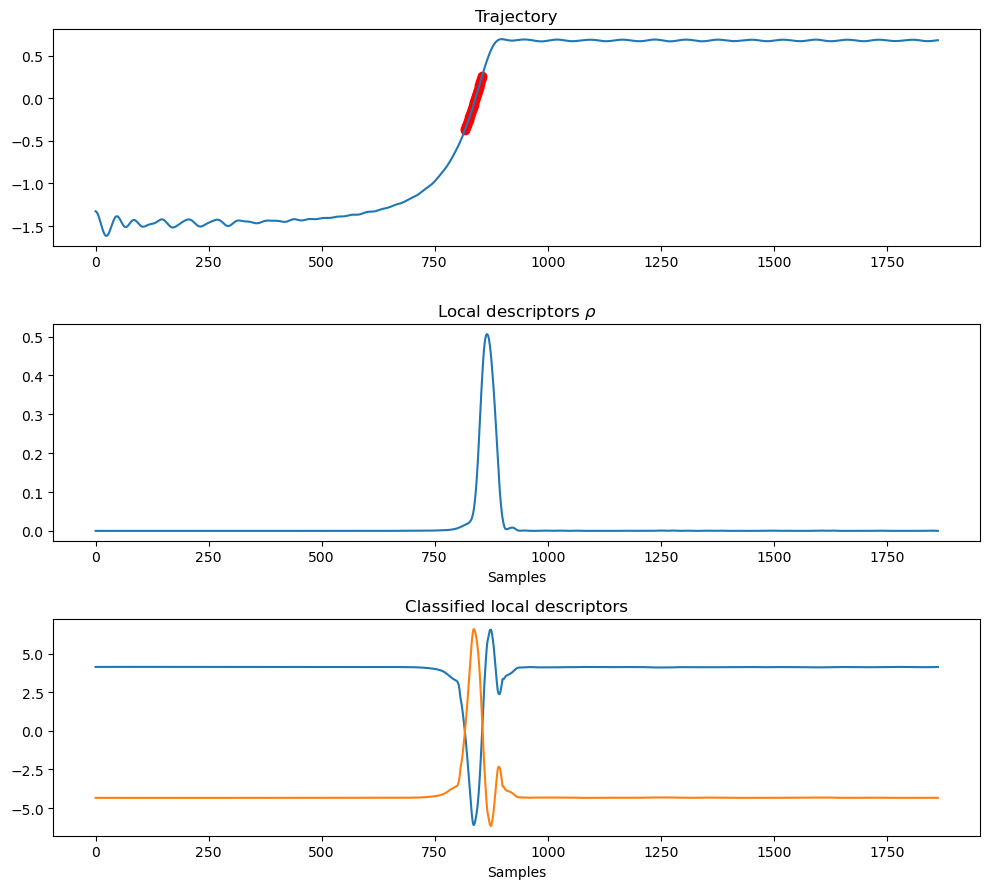

In [17]:
# --! display classification results --!

plt.figure(figsize=(10,9))

x = backs[jtraj][:, -1, 0]
x = x[desc_window_nsample:-desc_window_nsample]
x = x[class_window_nsample:-class_window_nsample]

t = np.arange(len(x))
i = classes[:, 0] < classes[:, 1]
plt.subplot(3,1,1)
plt.title('Trajectory')
plt.plot(x)
plt.scatter(t[i], x[t[i]], color='red')

d = descs[jtraj, :, 2]
plt.subplot(3,1,2)
plt.title('Local descriptors $\\rho$')
plt.plot(d)
plt.xlabel('Samples')

plt.subplot(3,1,3)
plt.title('Classified local descriptors')
plt.plot(classes)
plt.xlabel('Samples')

plt.tight_layout()
plt.show()

A metastable region is some neighborhood of an attracting invariant set. Learn a latent coordinate $c_t$. The coordinate evolves slowly inside regimes. The coordinate changes rapidly when the dynamics reorganize. That suggests defining risk through latent motion, not through a specific geometric interpretation.

We define metastable sets through persistence:

$$
\mathcal{N} = \{ z_t \; \colon \rho_t < \rho^{\star} \},
$$

and

$$
\mathcal{E} = \{ z_t \; \colon \rho_t \ge \rho^{\star} \},
$$

where $\rho_t = \lvert \frac{dc}{dt} \rvert$.

So a metastable set is a region where trajectories remain for long periods. Long residence time implies small latent velocity.

So conceptually the logic becomes

$$
z \rightarrow \rho \rightarrow \text{metastable regions}
$$

Advantage over immediate KMeans clustering:

* No need to choose the number of clusters
* No need to determine what cluster represents what